# HealthConnect Appointment Data Analysis

## Week 4: Exploratory Data Analysis

### Project Overview

This notebook explores appointment data from HealthConnect to understand patient appointment patterns and identify factors that may be associated with missed appointments.

The analysis focuses on understanding the structure and quality of the dataset, examining individual variables, and exploring relationships between appointment characteristics and appointment outcomes.

### Objectives

- Understand the structure and characteristics of the dataset.
- Assess the quality and consistency of the data.
- Explore distributions of key variables.
- Examine appointment outcomes across different patient and appointment characteristics.
- Identify preliminary patterns that may require further investigation.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df.shape

(5000, 18)

## 1. Dataset Overview

In [2]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [3]:
df.dtypes

appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object

In [4]:
df.shape

(5000, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

In [6]:
df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='str')

In [7]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


Dataset Overview

The HealthConnect appointment dataset contains 5,000 records and 18 variables. Each record represents a patient appointment and contains information covering patient demographics, appointment characteristics, booking history, reminder communication, accessibility, waiting time, and appointment outcomes.

The dataset contains identification variables, including "appointment_id" and "patient_id", as well as demographic variables such as "gender", "age", and "age_group". Appointment-related information includes "appointment_type", "booking_date", "appointment_date", "appointment_day", and "appointment_time".

The dataset also includes variables describing previous appointment behaviour, namely "booking_lead_days", "previous_appointments", and "previous_no_shows". Information about appointment reminders is captured through "reminder_sent" and "reminder_channel", while "distance_to_clinic_km" and "waiting_time_minutes" provide information about accessibility and the patient experience.

The main outcome variable is "appointment_outcome", which categorizes appointments as either Attended or No-Show. This variable will be used throughout the exploratory analysis to examine patterns associated with missed appointments.

An initial inspection of the dataset using "df.head()" shows that the variables contain both numerical and categorical information. Some variables, such as "reminder_channel", also contain missing values under certain circumstances—for example, when no reminder was sent. These observations will be examined more systematically during the data-quality assessment.

## 2. Data Quality Assessment

In [8]:
# Missing values
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [9]:
# Duplicates
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate appointment_id:', df['appointment_id'].duplicated().sum())

Duplicate rows: 0
Duplicate appointment_id: 0


In [10]:
# reminder_channel missingness is structural: confirm it aligns with reminder_sent == 'No'
mismatch = df[(df['reminder_sent']=='No') != (df['reminder_channel'].isnull())]
print('Mismatch rows (should be 0):', len(mismatch))

Mismatch rows (should be 0): 0


Duplicate Records

The dataset was examined for duplicate records using the "duplicated()" function. The analysis identified 0 duplicate rows across the dataset.

The "appointment_id" column was also checked for duplicate identifiers, and 0 duplicate appointment IDs were found. This indicates that each appointment record has a unique identifier and that there are no exact duplicate records requiring removal at this stage.

## 3. Preliminary Signal Checks (justifying proposed KPIs)

In [11]:
df['appointment_outcome'].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [12]:
no_show_rate = (df['appointment_outcome'] == 'No-Show').mean() * 100
no_show_rate

np.float64(48.46)

In [13]:
attendance_rate = (df['appointment_outcome'] == 'Attended').mean() * 100
attendance_rate

np.float64(46.28)

In [14]:
cancellation_rate = (df['appointment_outcome'] == 'Cancelled').mean() * 100
cancellation_rate

np.float64(5.26)

In [15]:
pd.crosstab(
    df['previous_no_shows'],
    df['appointment_outcome'],
    normalize='index'
) * 100

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.462170,6.025334,43.512496
1,42.248062,4.263566,53.488372
2,36.301370,4.337900,59.360731
3,29.487179,2.564103,67.948718
4,33.333333,0.000000,66.666667
5,0.000000,0.000000,100.000000


Appointment Outcome Distribution

The distribution of appointment outcomes shows that No-Show appointments are the most common outcome in the HealthConnect dataset. Out of the 5,000 appointments, 2,423 (48.46%) resulted in a No-Show, 2,314 (46.28%) were Attended, while 263 (5.26%) were Cancelled.

The relatively high proportion of No-Show appointments provides an initial signal that missed appointments are an important issue within the dataset. This supports the use of No-Show Rate as a primary KPI for the analysis.

Cancelled appointments are retained as a separate outcome rather than being automatically classified as No-Shows, since cancellation and failure to attend represent different appointment outcomes.

In [16]:
# No-show rate by prior no-show history
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,100], labels=['0','1','2','3+'])
df.groupby('prev_noshow_bucket')['appointment_outcome'].value_counts(normalize=True).unstack()

appointment_outcome,Attended,Cancelled,No-Show
prev_noshow_bucket,,,
0,0.504622,0.060253,0.435125
1,0.422481,0.042636,0.534884
2,0.363014,0.043379,0.593607
3+,0.290323,0.021505,0.688172


In [17]:
# No-show rate by reminder status
df.groupby('reminder_sent')['appointment_outcome'].value_counts(normalize=True).unstack()

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,0.426794,0.059297,0.513909
Yes,0.476335,0.050083,0.473583


In [18]:
# No-show rate by appointment type
df.groupby('appointment_type')['appointment_outcome'].value_counts(normalize=True).unstack()

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,0.458685,0.043845,0.497470
Follow-up,0.433498,0.054187,0.512315
General Consultation,0.482742,0.050815,0.466443
Specialist Consultation,0.465556,0.060000,0.474444


Previous No-Shows and Current Appointment Outcome

A preliminary comparison was conducted between patients' previous no-show history and their current appointment outcomes. The results indicate a generally increasing pattern in the proportion of current appointments resulting in a No-Show as previous no-shows increase.

Among patients with no previous no-shows, 43.51% of appointments resulted in a No-Show. This increased to 53.49% among patients with one previous no-show, 59.36% among those with two, and 67.95% among those with three previous no-shows. Patients with four previous no-shows recorded a No-Show rate of 66.67%, while the small group with five previous no-shows recorded 100% No-Shows.

This preliminary pattern suggests that previous no-show history may be an important signal associated with future appointment attendance. Consequently, previous no-shows should be considered when developing KPIs and conducting further analysis. However, the results represent an association rather than a causal relationship, and categories with very few observations should be interpreted cautiously.

In [19]:
no_show_by_history = (
    df.groupby('previous_no_shows')['appointment_outcome']
    .apply(lambda x: (x == 'No-Show').mean() * 100)
    .reset_index(name='no_show_rate')
)

no_show_by_history

,previous_no_shows,no_show_rate
0,0,43.512496
1,1,53.488372
2,2,59.360731
3,3,67.948718
4,4,66.666667
5,5,100.000000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

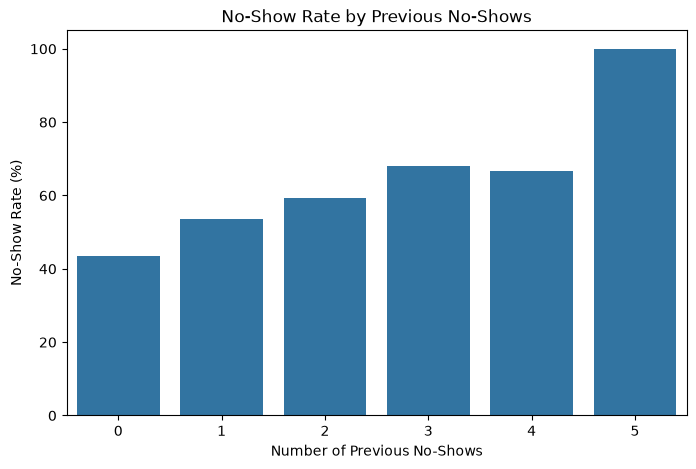

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(x='previous_no_shows', y='no_show_rate', data=no_show_by_history)
plt.title('No-Show Rate by Previous No-Shows')
plt.xlabel('Number of Previous No-Shows')
plt.ylabel('No-Show Rate (%)')
plt.show()

Interpretation: The visualization shows a generally positive relationship between previous no-show history and the likelihood of a current appointment resulting in a No-Show. Patients with a greater history of missed appointments generally have higher current No-Show rates. This preliminary signal supports further investigation of previous appointment behaviour as a potential indicator of future appointment attendance.

In [22]:
pd.crosstab(
    df['reminder_sent'],
    df['appointment_outcome'],
    normalize='index'
) * 100

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.679356,5.929722,51.390922
Yes,47.633462,5.008255,47.358283


Reminder Status and Appointment Outcome

A preliminary comparison was conducted between reminder status and appointment outcomes. The results show that appointments for which a reminder was sent had a No-Show rate of 47.36%, compared with 51.39% for appointments where no reminder was sent.

Appointments with reminders also had a higher attendance rate (47.63%) compared with appointments without reminders (42.68%). Cancellation rates were relatively similar, at 5.01% for appointments with reminders and 5.93% for appointments without reminders.

These results provide a preliminary signal that reminder status may be associated with appointment attendance. Therefore, reminder coverage and reminder effectiveness are reasonable candidates for further KPI analysis. However, this comparison alone does not establish that reminders cause patients to attend appointments, as other factors may influence the outcome.

In [23]:
pd.crosstab(
    pd.cut(df['booking_lead_days'], bins=[0, 7, 14, 30, 60, 90]),
    df['appointment_outcome'],
    normalize='index'
) * 100

appointment_outcome,Attended,Cancelled,No-Show
booking_lead_days,,,
"(0, 7]",65.945946,5.765766,28.288288
"(7, 14]",61.794020,4.651163,33.554817
"(14, 30]",51.687922,5.101275,43.210803
"(30, 60]",34.103093,5.402062,60.494845


Booking Lead Time and Appointment Outcome

A preliminary analysis was conducted to examine the relationship between booking lead time and appointment outcomes. Booking lead time was grouped into four intervals: 0–7 days, 8–14 days, 15–30 days, and 31–60 days.

The results show a clear increase in the No-Show rate as booking lead time increases. Appointments booked within 0–7 days had a No-Show rate of 28.29%, compared with 33.55% for appointments booked 8–14 days in advance. The rate increased further to 43.21% for appointments booked 15–30 days in advance and reached 60.49% for appointments booked 31–60 days in advance.

This provides a strong preliminary signal that longer booking lead times may be associated with a greater likelihood of missing an appointment. Therefore, booking lead time is a relevant variable for further analysis and can be considered when developing KPIs related to appointment attendance.

In [24]:
pd.crosstab(
    pd.cut(
        df['waiting_time_minutes'],
        bins=[0, 15, 30, 45, 60],
        include_lowest=True
    ),
    df['appointment_outcome'],
    normalize='index'
) * 100

appointment_outcome,Attended,Cancelled,No-Show
waiting_time_minutes,,,
"(-0.001, 15.0]",47.250699,5.684995,47.064306
"(15.0, 30.0]",45.024272,5.784790,49.190939
"(30.0, 45.0]",48.412698,3.809524,47.777778
"(45.0, 60.0]",46.969697,6.818182,46.212121


Waiting Time and Appointment Outcome

A preliminary analysis was conducted to examine whether waiting time is associated with appointment outcomes. Waiting time was grouped into four intervals: 0–15 minutes, 16–30 minutes, 31–45 minutes, and 46–60 minutes.

The No-Show rates across the four groups were relatively similar. Appointments with waiting times of 0–15 minutes had a No-Show rate of 47.06%, compared with 49.19% for 16–30 minutes, 47.78% for 31–45 minutes, and 46.21% for 46–60 minutes.

Unlike previous no-show history and booking lead time, waiting time does not show a clear preliminary relationship with appointment outcomes in this analysis. Although waiting time may still be relevant from an operational perspective, the results do not provide strong evidence at this stage that it is a major indicator of No-Show behaviour.

## 4. Important Variables

In [25]:
dictionary = pd.read_excel('HealthConnect_Data_Dictionary (1).xlsx')
dictionary.head()

,Variable,Data Type,Description,Example,Notes
0,appointment_id,Text,Unique appointment identifier,HC-00001,Primary key
1,patient_id,Text,Anonymised patient identifier,P-0421,May appear across multiple appointments
2,gender,Text,Recorded gender category,Female,Synthetic and anonymised
3,age,Integer,Patient age in years,34,Adult patients only
4,age_group,Text,Age band derived from age,25-34,Provided for descriptive analysis


In [26]:
dictionary.shape

(18, 5)

In [27]:
dictionary.columns

Index(['Variable', 'Data Type', 'Description', 'Example', 'Notes'], dtype='str')

In [28]:
dictionary[['Variable', 'Description', 'Notes']]

,Variable,Description,Notes
0,appointment_id,Unique appointment identifier,Primary key
1,patient_id,Anonymised patient identifier,May appear across multiple appointments
2,gender,Recorded gender category,Synthetic and anonymised
3,age,Patient age in years,Adult patients only
4,age_group,Age band derived from age,Provided for descriptive analysis
5,appointment_type,Type of scheduled appointment,Four appointment categories
6,booking_date,Date appointment was booked,ISO format
7,appointment_date,Scheduled appointment date,ISO format
8,appointment_day,Day of week for appointment,Derived from appointment date
9,appointment_time,Appointment time period,"Morning, Afternoon, Evening"


Important Variables

Based on the review of the HealthConnect Data Dictionary and dataset structure, several variables were identified as particularly relevant to investigating appointment attendance and no-show patterns.

- appointment_outcome: This is the primary outcome variable because it records whether an appointment was Attended, resulted in a No-Show, or was Cancelled.
- previous_no_shows: Records the number of previous missed appointments and may help identify patterns in repeated no-show behaviour.
- previous_appointments: Provides information about a patient's historical appointment activity and can provide context for previous no-show behaviour.
- booking_lead_days: Measures the number of days between booking and the scheduled appointment and may be relevant when examining whether longer waiting periods before an appointment are associated with no-shows.
- reminder_sent: Indicates whether an appointment reminder was sent and is relevant when investigating the potential relationship between reminders and attendance.
- reminder_channel: Identifies the channel used to deliver a reminder and may help compare different reminder methods.
- appointment_type: Identifies the type of appointment and may reveal differences in attendance across different types of healthcare services.
- appointment_day: Identifies the day of the week on which an appointment is scheduled and may help identify differences in attendance patterns across days.
- appointment_time: Records whether an appointment is scheduled in the Morning, Afternoon, or Evening and may be relevant when examining attendance patterns by time period.
- age_group: Provides age bands that can be used to examine whether attendance patterns differ across patient age groups.
- distance_to_clinic_km: Represents the approximate distance between the patient and clinic and may provide insight into whether accessibility is associated with appointment attendance.
- waiting_time_minutes: Represents estimated waiting time and may be relevant when considering operational factors associated with appointment outcomes.

These variables provide the foundation for developing the business questions and potential KPIs for the subsequent stages of the HealthConnect project.

5. Business Questions

Based on the project objective and the initial review of the HealthConnect appointment data, the following business questions will guide the subsequent analysis:

1. What is the overall level of appointment attendance, no-shows, and cancellations at HealthConnect?

2. Is previous no-show history associated with the likelihood of a patient missing a future appointment?

3. How are appointment reminders and reminder channels related to appointment attendance and no-show patterns?

4. Is the length of time between booking and the scheduled appointment associated with appointment no-shows?

5. Do appointment characteristics, such as appointment type, day, and time, show differences in attendance and no-show patterns?

These questions will provide a focused basis for identifying relevant KPIs and determining the direction of the subsequent exploratory analysis.

## 6. Proposed KPIs

Based on the review of the dataset, data dictionary, and preliminary exploration, five potential KPIs have been identified for further investigation. These KPIs are intended to provide measurable indicators for the business questions identified above. At this stage, the KPIs are proposed and justified only; detailed calculation and analysis will be conducted in subsequent stages.

| Potential KPI | Linked Business Question | Justification |
|---|---|---|
| **No-Show Rate** | What is the overall level of appointment attendance, no-shows, and cancellations? | Measures the proportion of scheduled appointments that are missed and establishes the overall scale of the no-show problem. |
| **Repeat No-Show Rate** | Is previous no-show history associated with the likelihood of a patient missing a future appointment? | Helps identify whether patients with a history of missed appointments are more likely to miss subsequent appointments. |
| **Reminder Coverage Rate** | How are appointment reminders and reminder channels related to appointment attendance and no-show patterns? | Measures the proportion of appointments for which reminders are sent and provides an indicator of reminder reach. |
| **No-Show Rate by Booking Lead-Time Group** | Is the length of time between booking and the scheduled appointment associated with appointment no-shows? | Allows comparison of no-show patterns across different booking lead-time periods. |
| **No-Show Rate by Appointment Type** | Do appointment characteristics show differences in attendance and no-show patterns? | Allows comparison of no-show patterns across different appointment categories and may identify appointment types requiring further investigation. |

These KPIs provide a focused starting point for the subsequent analysis and may be refined as further analysis identifies the factors most strongly associated with appointment attendance and no-shows.

# Week 5: Exploratory Analysis, KPI Development & Business Insights

## 1. Week 4 → Week 5 Transition

### Problem Defined

HealthConnect Clinic aims to reduce missed appointments, better understand appointment attendance patterns, improve the use of appointment slots, and provide more effective administrative support to patients.

### Week 4 Proposed Approach

In Week 4, the appointment dataset and data dictionary were reviewed, the quality of the data was assessed, relevant variables were identified, business questions were defined, and potential KPIs were proposed. Preliminary checks were also conducted to identify possible patterns in appointment outcomes.

### Relevant HealthConnect Resources

The main resources used are:

- HealthConnect Appointment Dataset
- HealthConnect Data Dictionary
- Python and Jupyter Notebook for data analysis

### Key Assumptions and Limitations

The dataset is fictional and anonymised. The analysis is therefore intended to identify patterns within the available data rather than establish causal relationships. The analysis is also limited to the variables and information provided in the HealthConnect dataset.

### Week 5 Focus

In Week 5, the analysis will move from preliminary exploration to practical implementation. The focus will be on preparing the data, conducting exploratory data analysis, calculating and interpreting selected KPIs, developing visualisations, identifying meaningful business insights, and providing recommendations for HealthConnect.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print(df.shape)
df.head()

(5000, 18)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


# DATA PREPARATION

In [29]:
# Create a separate working copy for Week 5 analysis
df_clean = df.copy()

print("Working dataset created.")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Working dataset created.
Rows: 5000
Columns: 19


In [30]:
df_clean.columns.tolist()

['appointment_id',
 'patient_id',
 'gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'reminder_sent',
 'reminder_channel',
 'distance_to_clinic_km',
 'waiting_time_minutes',
 'appointment_outcome',
 'prev_noshow_bucket']

In [31]:
# Remove the temporary Week 4 analysis column
df_clean = df_clean.drop(columns=['prev_noshow_bucket'])

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 5000
Columns: 18


In [32]:
# Check missing values in each variable
missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64

In [33]:
# Check whether missing reminder channels correspond to appointments
# where no reminder was sent
pd.crosstab(
    df_clean['reminder_sent'],
    df_clean['reminder_channel'],
    dropna=False
)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


In [40]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


In [41]:
# Duplicates
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate appointment_id:', df['appointment_id'].duplicated().sum())

Duplicate rows: 0
Duplicate appointment_id: 0


In [42]:
# Inconsistent / unexpected categorical values
for col in ['gender', 'appointment_type', 'appointment_day', 'appointment_time',
            'reminder_sent', 'reminder_channel', 'appointment_outcome']:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

gender: ['Female', 'Male', 'Prefer not to say']
appointment_type: ['Diagnostic Test', 'Follow-up', 'General Consultation', 'Specialist Consultation']
appointment_day: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
appointment_time: ['Afternoon', 'Evening', 'Morning']
reminder_sent: ['No', 'Yes']
reminder_channel: ['Email', 'SMS', 'WhatsApp']
appointment_outcome: ['Attended', 'Cancelled', 'No-Show']


In [43]:
# Range checks on numeric fields
print('age range:', df['age'].min(), '-', df['age'].max())
print('booking_lead_days range:', df['booking_lead_days'].min(), '-', df['booking_lead_days'].max())
print('distance_to_clinic_km range:', df['distance_to_clinic_km'].min(), '-', df['distance_to_clinic_km'].max())
print('waiting_time_minutes range:', df['waiting_time_minutes'].min(), '-', df['waiting_time_minutes'].max())
print('previous_no_shows > previous_appointments:', (df['previous_no_shows'] > df['previous_appointments']).sum())

age range: 18 - 80
booking_lead_days range: 0 - 60
distance_to_clinic_km range: 0.5 - 45.0
waiting_time_minutes range: 2.0 - 68.0
previous_no_shows > previous_appointments: 0


## Data Quality Observations

- No duplicate rows or duplicate `appointment_id` values — the dataset has a clean primary key.
- All categorical fields contain only expected, consistently-formatted values — no typos or casing issues.
- All range and logical consistency checks pass (ages are adult-only, lead times are non-negative, no-show counts never exceed appointment counts).
- Three fields contain missing values: `reminder_channel` (27.3%, structural — only populated when a reminder was sent), `distance_to_clinic_km` (1.8%), and `waiting_time_minutes` (1.2%).

## Cleaning Decisions Applied

- `reminder_channel` — fill missing values with `"No Reminder"` as an explicit category, since the null is structural, not an error.
- `distance_to_clinic_km` and `waiting_time_minutes` — impute missing values with the median (robust to outliers, low volume of missingness, and neither field showed a strong relationship with the missingness pattern itself in Week 4).
- A `_was_missing` flag is kept for each field in case this needs revisiting.

In [44]:
df_clean = df.copy()

# 1. reminder_channel: structural missing -> explicit category
df_clean['reminder_channel'] = df_clean['reminder_channel'].fillna('No Reminder')

# 2. distance_to_clinic_km and waiting_time_minutes: median imputation, with missingness flags retained
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    df_clean[f'{col}_was_missing'] = df_clean[col].isnull()
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: filled {df_clean[f'{col}_was_missing'].sum()} missing values with median {median_val}")

# Parse dates
df_clean['booking_date'] = pd.to_datetime(df_clean['booking_date'])
df_clean['appointment_date'] = pd.to_datetime(df_clean['appointment_date'])

print('\nRemaining missing values:', df_clean.isnull().sum().sum())

distance_to_clinic_km: filled 90 missing values with median 8.7
waiting_time_minutes: filled 60 missing values with median 24.0

Remaining missing values: 0


In [45]:
# Save the cleaned dataset separately -- original file is untouched
df_clean.to_csv('HealthConnect_Appointment_Data_cleaned.csv', index=False)
print('Saved: HealthConnect_Appointment_Data_cleaned.csv')

Saved: HealthConnect_Appointment_Data_cleaned.csv


## Exploratory Data Analysis
This section investigates appointment attendance and no-show patterns across appointment characteristics, patient characteristics, previous appointment history, reminders, waiting time, distance, and cancellations.

 # Overall Outcome Distribution

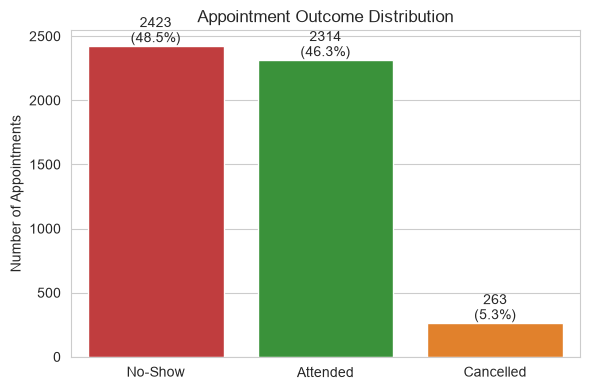

In [46]:
outcome_counts = df_clean['appointment_outcome'].value_counts()
outcome_pct = df_clean['appointment_outcome'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index,
            palette=['#d62728', '#2ca02c', '#ff7f0e'], legend=False, ax=ax)
ax.set_title('Appointment Outcome Distribution')
ax.set_ylabel('Number of Appointments')
ax.set_xlabel('')
for i, (count, pct) in enumerate(zip(outcome_counts.values, outcome_pct.values)):
    ax.text(i, count + 30, f'{count}\n({pct:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

# Observation: 
No-Show (48.5%) and Attended (46.3%) are nearly equal in volume, with Cancelled a distinct minority (5.3%). This confirms no-shows are a large-scale, systemic issue rather than a rare event.

# Patient Characteristics: Age and Gender

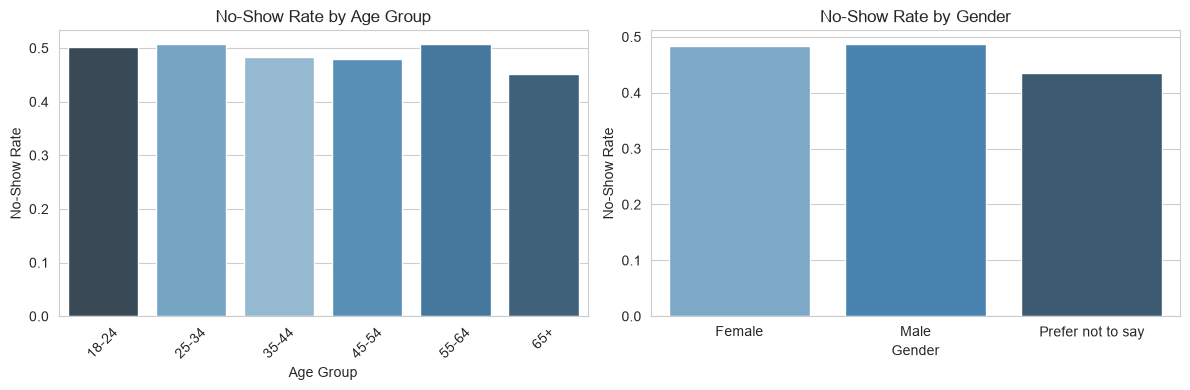

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

age_order = sorted(df_clean['age_group'].unique())
sns.barplot(data=df_clean, x='age_group', y=(df_clean['appointment_outcome']=='No-Show').astype(int),
            order=age_order, hue='age_group', palette='Blues_d', legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('No-Show Rate by Age Group')
axes[0].set_ylabel('No-Show Rate')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_clean, x='gender', y=(df_clean['appointment_outcome']=='No-Show').astype(int),
            hue='gender', palette='Blues_d', legend=False, ax=axes[1], errorbar=None)
axes[1].set_title('No-Show Rate by Gender')
axes[1].set_ylabel('No-Show Rate')
axes[1].set_xlabel('Gender')

plt.tight_layout()
plt.show()

# Observation: 
No-show rates are broadly similar across age groups and gender — neither shows a strong standalone pattern, suggesting demographic segmentation alone is not a strong lever for this problem.

# Previous Appointment History

In [48]:
df_clean['prev_noshow_bucket'] = pd.cut(df_clean['previous_no_shows'], bins=[-1,0,1,2,100], labels=['0','1','2','3+'])
prev_table = df_clean.groupby('prev_noshow_bucket', observed=True)['appointment_outcome'].value_counts(normalize=True).unstack() * 100
prev_table

appointment_outcome,Attended,Cancelled,No-Show
prev_noshow_bucket,,,
0,50.462170,6.025334,43.512496
1,42.248062,4.263566,53.488372
2,36.301370,4.337900,59.360731
3+,29.032258,2.150538,68.817204


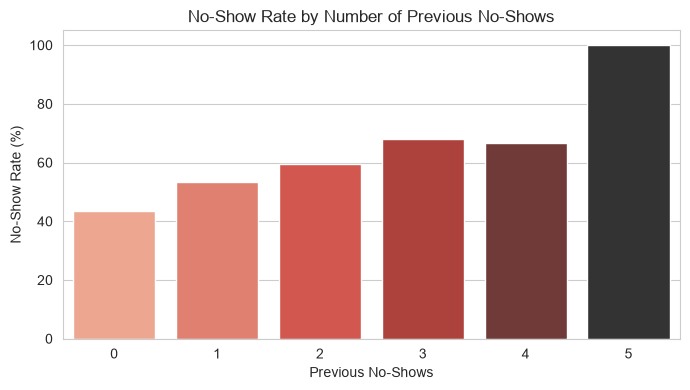

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
no_show_by_history = df_clean.groupby('previous_no_shows')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100).reset_index(name='no_show_rate')
sns.barplot(data=no_show_by_history, x='previous_no_shows', y='no_show_rate', hue='previous_no_shows', palette='Reds_d', legend=False, ax=ax)
ax.set_title('No-Show Rate by Number of Previous No-Shows')
ax.set_xlabel('Previous No-Shows')
ax.set_ylabel('No-Show Rate (%)')
plt.tight_layout()
plt.show()

# Observation:
A clear escalating pattern — No-Show rate rises from ~43.5% (0 prior no-shows) to ~68% (3 prior no-shows). Prior attendance behaviour is one of the strongest signals in the dataset.

# Reminders

In [50]:
reminder_table = df_clean.groupby('reminder_sent')['appointment_outcome'].value_counts(normalize=True).unstack() * 100
reminder_table

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.679356,5.929722,51.390922
Yes,47.633462,5.008255,47.358283


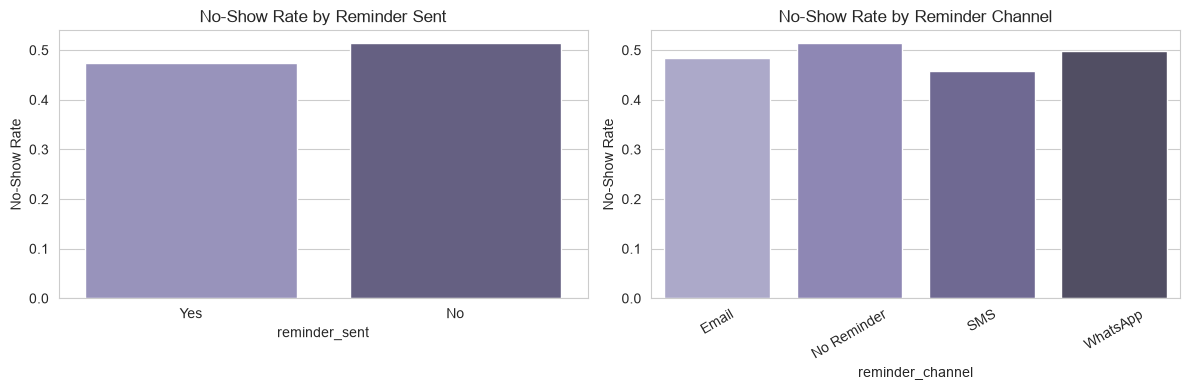

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df_clean, x='reminder_sent', y=(df_clean['appointment_outcome']=='No-Show').astype(int),
            hue='reminder_sent', palette='Purples_d', legend=False, ax=axes[0], errorbar=None)
axes[0].set_title('No-Show Rate by Reminder Sent')
axes[0].set_ylabel('No-Show Rate')

channel_rate = df_clean.groupby('reminder_channel')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()).reset_index(name='no_show_rate')
sns.barplot(data=channel_rate, x='reminder_channel', y='no_show_rate', hue='reminder_channel', palette='Purples_d', legend=False, ax=axes[1])
axes[1].set_title('No-Show Rate by Reminder Channel')
axes[1].set_ylabel('No-Show Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Observation:
Sending a reminder is associated with a modestly lower No-Show rate (47.4% vs 51.4%). No single channel stands out strongly, though this is worth revisiting with a larger, more controlled comparison

# Waiting Time and Distance to Clinic

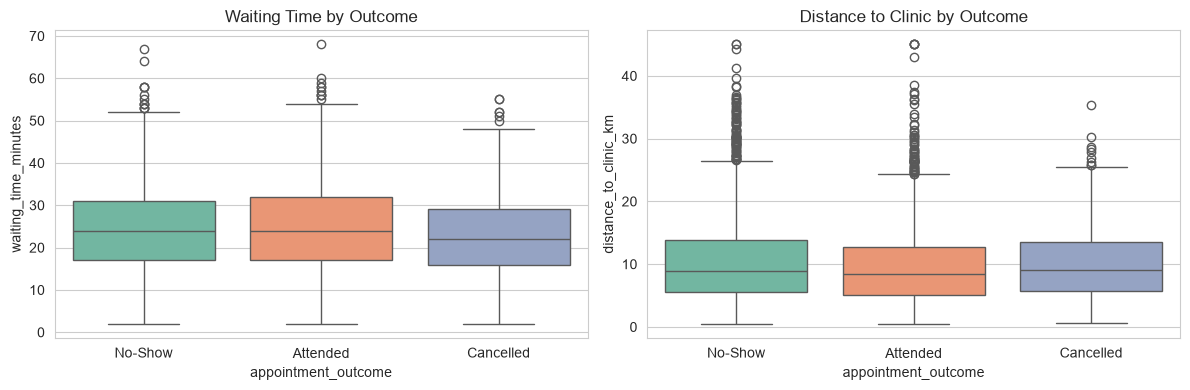

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_clean, x='appointment_outcome', y='waiting_time_minutes', hue='appointment_outcome', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Waiting Time by Outcome')

sns.boxplot(data=df_clean, x='appointment_outcome', y='distance_to_clinic_km', hue='appointment_outcome', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Distance to Clinic by Outcome')

plt.tight_layout()
plt.show()

# Observation: 
Distributions of waiting time and distance to clinic are very similar across Attended, No-Show, and Cancelled outcomes (overlapping boxes, similar medians). Neither shows a strong visual relationship with attendance — consistent with the weak signal already found in Week 4.

# Booking lead time

In [53]:
df_clean['lead_time_group'] = pd.cut(df_clean['booking_lead_days'], bins=[-1,7,14,30,60,1000],
                                       labels=['0-7 days','8-14 days','15-30 days','31-60 days','60+ days'])
lead_table = df_clean.groupby('lead_time_group', observed=True)['appointment_outcome'].value_counts(normalize=True).unstack() * 100
lead_table

appointment_outcome,Attended,Cancelled,No-Show
lead_time_group,,,
0-7 days,66.562500,5.625000,27.812500
8-14 days,61.794020,4.651163,33.554817
15-30 days,51.687922,5.101275,43.210803
31-60 days,34.103093,5.402062,60.494845


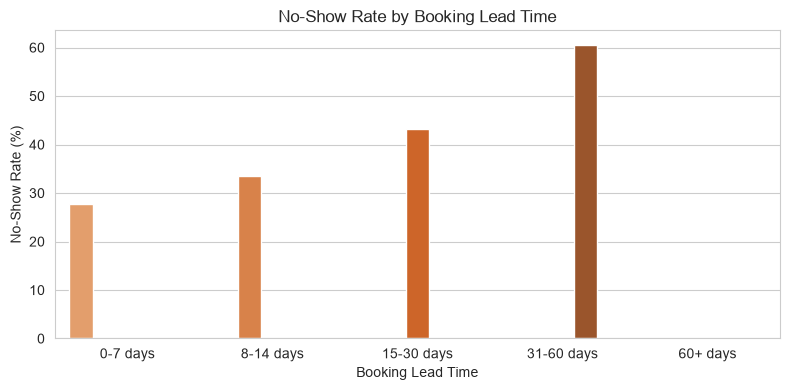

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))
lead_rate = df_clean.groupby('lead_time_group', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100).reset_index(name='no_show_rate')
sns.barplot(data=lead_rate, x='lead_time_group', y='no_show_rate', hue='lead_time_group', palette='Oranges_d', legend=False, ax=ax)
ax.set_title('No-Show Rate by Booking Lead Time')
ax.set_xlabel('Booking Lead Time')
ax.set_ylabel('No-Show Rate (%)')
plt.tight_layout()
plt.show()

# Observation: 
The strongest pattern in the dataset. No-Show rate climbs steadily from ~28% (booked 0-7 days ahead) to ~60%+ for appointments booked over a month in advance. Patients booked far in advance are far more likely to forget or deprioritise the appointment.

# Appointment Type, Day and Time

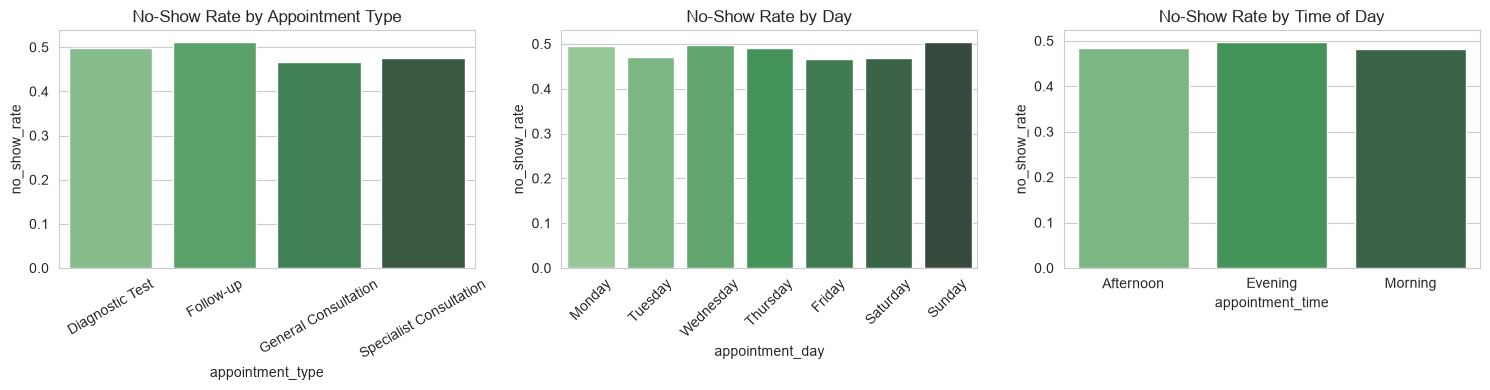

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

type_rate = df_clean.groupby('appointment_type')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()).reset_index(name='no_show_rate')
sns.barplot(data=type_rate, x='appointment_type', y='no_show_rate', hue='appointment_type', palette='Greens_d', legend=False, ax=axes[0])
axes[0].set_title('No-Show Rate by Appointment Type')
axes[0].tick_params(axis='x', rotation=30)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rate = df_clean.groupby('appointment_day')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()).reindex(day_order).reset_index(name='no_show_rate')
sns.barplot(data=day_rate, x='appointment_day', y='no_show_rate', hue='appointment_day', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('No-Show Rate by Day')
axes[1].tick_params(axis='x', rotation=45)

time_rate = df_clean.groupby('appointment_time')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()).reset_index(name='no_show_rate')
sns.barplot(data=time_rate, x='appointment_time', y='no_show_rate', hue='appointment_time', palette='Greens_d', legend=False, ax=axes[2])
axes[2].set_title('No-Show Rate by Time of Day')

plt.tight_layout()
plt.show()

# Observation: 
No-show rate varies only slightly across appointment type, day of week, and time of day — none stand out as a major independent driver, though Specialist Consultations and later-week appointments are worth monitoring as the dataset grows.

# Cancellations — A Distinct Outcome

In [56]:
cancel_by_type = df_clean.groupby('appointment_type')['appointment_outcome'].apply(lambda x: (x=='Cancelled').mean()*100).reset_index(name='cancellation_rate')
cancel_by_type

,appointment_type,cancellation_rate
0,Diagnostic Test,4.384486
1,Follow-up,5.418719
2,General Consultation,5.081496
3,Specialist Consultation,6.000000


### Observation: Appointment Cancellations

- Cancellation rates are low (~5%) and fairly consistent across appointment types.
- Cancellations behave differently from **No-Shows** and should be tracked as a separate metric rather than folded into the No-Show KPI.
- A **cancellation** is typically patient-initiated and the appointment slot may still be recoverable.
- A **No-Show** occurs without the patient attending or providing notice, meaning the appointment slot is generally wasted.
- Therefore, cancellations and No-Shows have different operational implications and should be monitored separately.

# KPI DevelopmentFive KPIs were proposed in Week 4. Each is now formally defined, calculated, and interpreted against its linked business question.

# KPI 1 — Overall No-Show Rate**Definition**: The percentage of all scheduled appointments that result in a No-Show. Why it matters: Establishes the baseline scale of the problem and gives a single number to track over time as interventions are introduced.#  Linked business question: What is the overall level of appointment attendance, no-shows, and cancellations?

In [35]:
overall_no_show_rate = (df_clean['appointment_outcome'] == 'No-Show').mean() * 100
print(f"Overall No-Show Rate: {overall_no_show_rate:.2f}%")

Overall No-Show Rate: 48.46%


**Interpretation**: Just under half of all appointments (48.46%) are missed. This is a large, costly problem — every percentage point reduction represents dozens of recovered appointment slots per thousand bookings.

## KPI 2 — Repeat No-Show Rate**Definition**: The No-Show rate among patients who have at least one previous no-show, compared with patients who have none. Why it matters: Identifies whether past behaviour predicts future behaviour, which determines whether the clinic should target repeat offenders with tailored outreach. Linked business question: Is previous no-show history associated with the likelihood of a patient missing a future appointment?

In [36]:
has_prior_noshow = df_clean['previous_no_shows'] > 0
repeat_rate = df_clean.loc[has_prior_noshow, 'appointment_outcome'].eq('No-Show').mean() * 100
first_time_rate = df_clean.loc[~has_prior_noshow, 'appointment_outcome'].eq('No-Show').mean() * 100
print(f"No-Show Rate (patients with prior no-shows): {repeat_rate:.2f}%")
print(f"No-Show Rate (patients with no prior no-shows): {first_time_rate:.2f}%")
print(f"Difference: {repeat_rate - first_time_rate:.2f} percentage points")

No-Show Rate (patients with prior no-shows): 55.41%
No-Show Rate (patients with no prior no-shows): 43.51%
Difference: 11.90 percentage points


**Interpretation**: Patients with a history of no-shows are substantially more likely to miss future appointments than first-timers. This is the strongest patient-level signal found and a strong candidate feature for the Data Science track's prediction model.

## KPI 3 — Reminder Coverage Rate**Definition**: The percentage of appointments for which a reminder was sent. Why it matters: Measures how completely the clinic's reminder process is being applied — a low coverage rate signals an operational gap that's directly fixable, independent of whether reminders work. Linked business question: How are appointment reminders and reminder channels related to appointment attendance and no-show patterns?

In [37]:
reminder_coverage_rate = (df_clean['reminder_sent'] == 'Yes').mean() * 100
print(f"Reminder Coverage Rate: {reminder_coverage_rate:.2f}%")

# Effectiveness context (paired with coverage)
no_show_with_reminder = df_clean.loc[df_clean['reminder_sent']=='Yes', 'appointment_outcome'].eq('No-Show').mean()*100
no_show_without_reminder = df_clean.loc[df_clean['reminder_sent']=='No', 'appointment_outcome'].eq('No-Show').mean()*100
print(f"No-Show Rate WITH reminder: {no_show_with_reminder:.2f}%")
print(f"No-Show Rate WITHOUT reminder: {no_show_without_reminder:.2f}%")

Reminder Coverage Rate: 72.68%
No-Show Rate WITH reminder: 47.36%
No-Show Rate WITHOUT reminder: 51.39%


**Interpretation**: Reminders reach roughly three-quarters of appointments, leaving a meaningful minority with no reminder at all. Since reminders are associated with a ~4 percentage point lower No-Show rate, closing this coverage gap is a low-cost, directly actionable improvement.

## KPI 4 — No-Show Rate by Booking Lead-Time Group**Definition**: No-Show rate segmented into booking lead-time bands (0–7, 8–14, 15–30, 31–60, 60+ days). Why it matters: Identifies whether the time between booking and the appointment itself is a driver of no-shows, pointing toward scheduling-policy interventions. Linked business question: Is the length of time between booking and the scheduled appointment associated with appointment no-shows?

In [58]:
lead_time_kpi = df_clean.groupby('lead_time_group', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100).round(2)
lead_time_kpi

lead_time_group
0-7 days      27.81
8-14 days     33.55
15-30 days    43.21
31-60 days    60.49
Name: appointment_outcome, dtype: float64

**Interpretation**: This is the strongest relationship found in the dataset. No-Show rate more than doubles between appointments booked within a week (~28%) and those booked over a month out (~60%+). This strongly suggests the clinic should apply extra reminder touchpoints — or reconsider default scheduling windows — for appointments booked far in advance.

## KPI 5 — No-Show Rate by Appointment Type**Definition**: No-Show rate segmented by appointment_type (e.g. General Consultation, Follow-up, Specialist Consultation). Why it matters: Identifies whether specific service types are disproportionately affected, helping the clinic prioritise where to focus engagement resources. Linked business question: Do appointment characteristics, such as appointment type, day, and time, show differences in attendance and no-show patterns?

In [59]:
type_kpi = df_clean.groupby('appointment_type')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()*100).round(2).sort_values(ascending=False)
type_kpi

appointment_type
Follow-up                  51.23
Diagnostic Test            49.75
Specialist Consultation    47.44
General Consultation       46.64
Name: appointment_outcome, dtype: float64

**Interpretation**: No-show rates are fairly close across appointment types, with no single type standing out as dramatically worse. This suggests appointment type alone is a weaker lever than booking lead time or prior history, though it remains useful for reporting granularity.

# Analytical Dashboard
A single combined view of the five KPIs, intended as an at-a-glance summary for HealthConnect stakeholders.

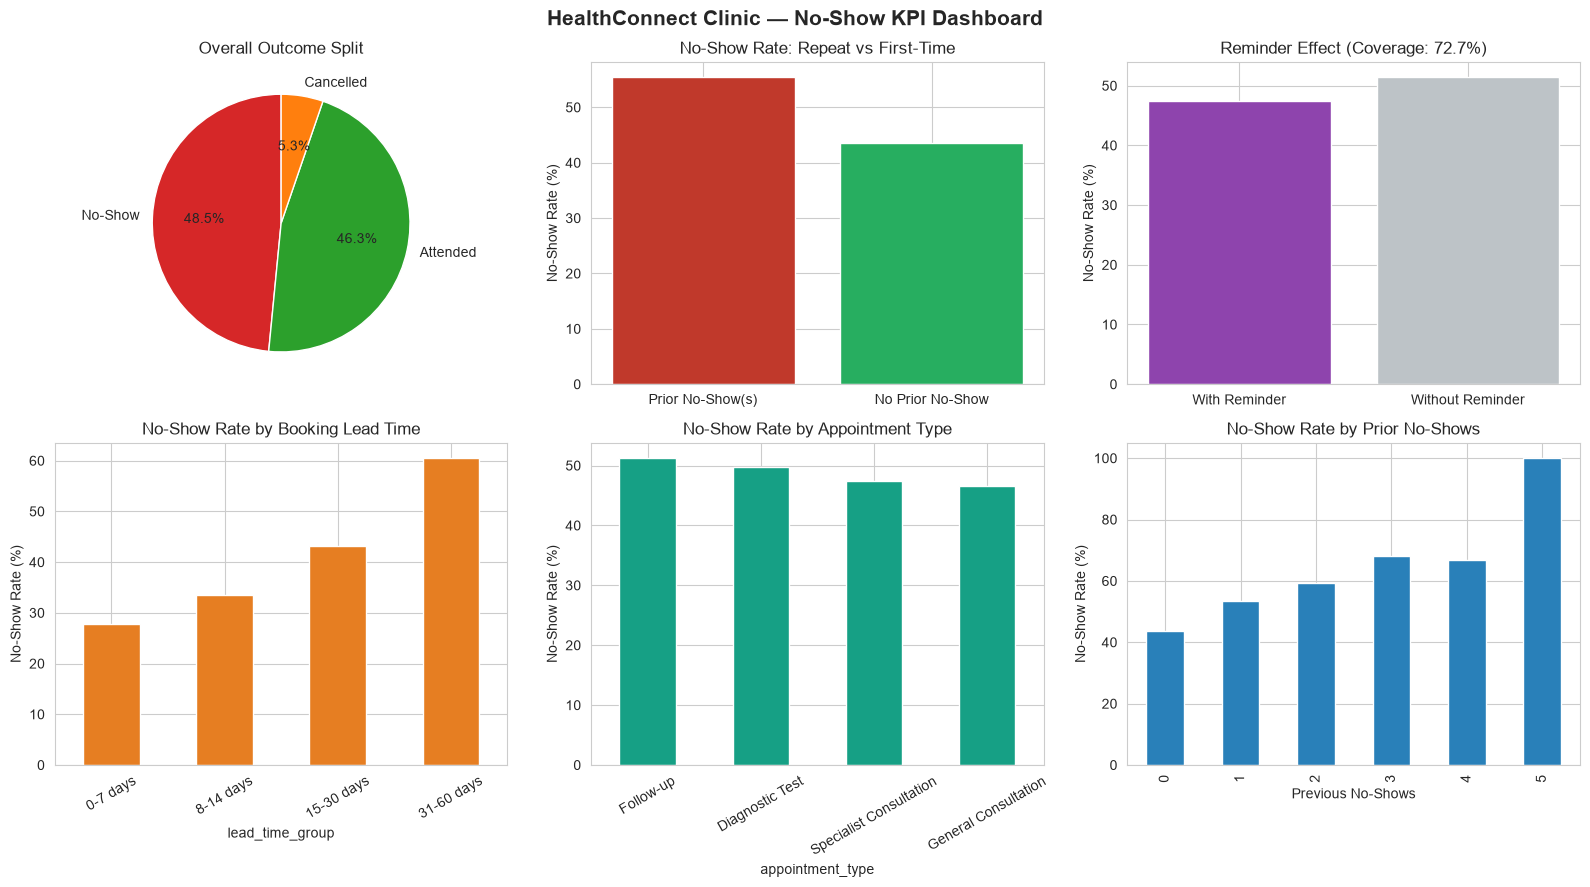

Dashboard saved as HealthConnect_Week5_Dashboard.png


In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('HealthConnect Clinic — No-Show KPI Dashboard', fontsize=15, fontweight='bold')

# 1. Overall outcome split
axes[0,0].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%',
              colors=['#d62728','#2ca02c','#ff7f0e'], startangle=90)
axes[0,0].set_title('Overall Outcome Split')

# 2. Repeat vs first-time no-show rate
axes[0,1].bar(['Prior No-Show(s)', 'No Prior No-Show'], [repeat_rate, first_time_rate], color=['#c0392b','#27ae60'])
axes[0,1].set_title('No-Show Rate: Repeat vs First-Time')
axes[0,1].set_ylabel('No-Show Rate (%)')

# 3. Reminder coverage + effect
axes[0,2].bar(['With Reminder','Without Reminder'], [no_show_with_reminder, no_show_without_reminder], color=['#8e44ad','#bdc3c7'])
axes[0,2].set_title(f'Reminder Effect (Coverage: {reminder_coverage_rate:.1f}%)')
axes[0,2].set_ylabel('No-Show Rate (%)')

# 4. Lead time
lead_time_kpi.plot(kind='bar', ax=axes[1,0], color='#e67e22')
axes[1,0].set_title('No-Show Rate by Booking Lead Time')
axes[1,0].set_ylabel('No-Show Rate (%)')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Appointment type
type_kpi.plot(kind='bar', ax=axes[1,1], color='#16a085')
axes[1,1].set_title('No-Show Rate by Appointment Type')
axes[1,1].set_ylabel('No-Show Rate (%)')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Previous no-shows escalation
no_show_by_history.plot(kind='bar', x='previous_no_shows', y='no_show_rate', ax=axes[1,2], color='#2980b9', legend=False)
axes[1,2].set_title('No-Show Rate by Prior No-Shows')
axes[1,2].set_ylabel('No-Show Rate (%)')
axes[1,2].set_xlabel('Previous No-Shows')

plt.tight_layout()
plt.savefig('HealthConnect_Week5_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as HealthConnect_Week5_Dashboard.png')

## Business Insights and Recommendations

| # | Insight | Implication for HealthConnect |
|---|---|---|
| 1 | **Nearly half of all appointments (48.46%) end in a No-Show.** | This is a large-scale, systemic issue, not an edge case — it justifies dedicated resourcing rather than a minor process tweak. |
| 2 | **Booking lead time is the strongest driver found:** No-Show rate rises from ~28% (0–7 days) to over 60% (31–60+ days). | Introduce extra reminder touchpoints (e.g. a mid-point reminder, not just a day-before one) for appointments booked far in advance, or consider shorter default booking windows for high-risk services. |
| 3 | **Patients with prior no-shows are substantially more likely to miss future appointments than first-timers.** | Build a **"high-risk patient" flag** using no-show history to enable proactive outreach (e.g. phone confirmation instead of SMS) for repeat no-show patients. |
| 4 | **Reminders are associated with a modestly lower No-Show rate (47.4% vs 51.4%), but coverage is only ~73%.** | Closing the reminder coverage gap is a low-cost, high-leverage fix — every appointment should receive at least one reminder before considering channel optimisation. |
| 5 | **Waiting time and distance to clinic show little to no relationship with attendance.** | These operational factors are lower priority for no-show reduction; resources are better spent on lead-time management and patient history-based outreach. |
| 6 | **Cancellations (5.3%) behave differently from No-Shows and are fairly consistent across appointment types.** | Continue tracking cancellations as a separate metric from no-shows — conflating the two would understate the true silent no-show problem. |

### Overall Recommendation

**HealthConnect should prioritise two interventions for the highest expected impact:**

1. **A booking lead-time-aware reminder cadence**
2. **A risk-flagging system for patients with prior no-shows**

Both are directly supported by the strongest signals in this analysis and require **no new data collection** to implement.to implement.

## Cross-Track Collaboration**Track interacted with**: Data Science.**Information exchanged**: The KPI and EDA findings above — specifically that booking_lead_days and previous_no_shows show the strongest association with appointment_outcome, while waiting_time_minutes and distance_to_clinic_km show weak association — were shared as candidate feature prioritie.

Why it was relevant: The Data Science track is defining a no-show prediction model in Week 5 and needs to know which features are likely to carry predictive signal before finalising the featur set.

What changed/improevd r**s*lt: This gives the Data Science track an evidence-based starting point for feature selection, rather than treating all 18 variables as equally likely candidates, and flags that the treatment of Cancelled appointments should be aligned between the two tracks since both rely on the same appointment_outcome field.

## Assumptions, Limitations, Risks and Dependencies — Week 5 Update

### Remain Relevant (Unchanged from Week 4)

- The dataset is **fictional/synthetic**; findings support the learning exercise but are not validated against real clinic data.
- All relationships identified are **associations, not proven causes**.
- Some `previous_no_shows` categories (e.g. **4–5 prior no-shows**) have very few observations and should be interpreted cautiously.

### Resolved This Week

- The structural nature of `reminder_channel` missingness (flagged in Week 4) has now been formally handled by encoding it as an explicit **"No Reminder"** category.
- Missing values in `distance_to_clinic_km` and `waiting_time_minutes` have been resolved via **median imputation**, with `_was_missing` flags retained for transparency.

### Changed Since Week 4

- `waiting_time_minutes` and `distance_to_clinic_km`, initially flagged as plausible drivers, now show **weak/no relationship with attendance** after fuller EDA — lowered in priority as candidate KPIs/features.

### New Issues Discovered This Week

- **Reminder coverage (73%) is lower than expected**, revealing an operational gap not visible from the Week 4 review alone.

### Potential Impact and Mitigation

- The lead-time and history-based patterns are strong enough to act on with reasonable confidence.
- However, recommendations should be framed as **"associated with" rather than "causes of" no-shows**.
- Recommendations should ideally be validated through a **controlled follow-up**, such as A/B testing a new reminder cadence, before being treated as fully proven.

## Limitations of This Analysis

- Findings reflect **correlation, not causation** — e.g. we cannot conclude that reminders cause attendance without a controlled experiment.

- Median imputation for `distance_to_clinic_km` and `waiting_time_minutes` slightly reduces variance in those fields; only **1.8% and 1.2% of records** were affected, so the impact is expected to be minor.

- The dataset spans appointments from **January 2025 to June 2026** without explicit seasonality analysis — trends over time (e.g. holiday periods) were not investigated this week.

- Small sample sizes in the highest `previous_no_shows` categories make those specific rates **less statistically reliable** than the overall pattern.